# BC Rollout Analysis
Reads rollout HDF5 logs and plots policy behavior for debugging and evaluation.

In [1]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path(os.path.abspath('')).parent
LOG_ROOT  = REPO_ROOT / 'logs' / 'rollouts'

print(f'Repo root: {REPO_ROOT}')
print(f'Log root:  {LOG_ROOT}')
print(f'Exists:    {LOG_ROOT.exists()}')

Repo root: /Users/alex/Workspace/projects/bc-rl-manipulation
Log root:  /Users/alex/Workspace/projects/bc-rl-manipulation/logs/rollouts
Exists:    True


## 1. Available rollout files

In [2]:
rollout_files = sorted(LOG_ROOT.glob('rollout_*.h5'))
print(f'Found {len(rollout_files)} rollout file(s):')
for f in rollout_files:
    with h5py.File(f, 'r') as h:
        n_eps     = len(h.keys())
        successes = sum(h[ep].attrs['success'] for ep in h.keys())
        print(f'  {f.name}: {n_eps} episodes, {successes}/{n_eps} success')

Found 1 rollout file(s):
  rollout_20260503_134917.h5: 2 episodes, 0/2 success


## 2. Select rollout file and load all episodes

In [3]:
ROLLOUT_FILE = rollout_files[-1]  # change index to select a different file
print(f'Loading: {ROLLOUT_FILE.name}')

episodes = []
with h5py.File(ROLLOUT_FILE, 'r') as f:
    for ep_key in sorted(f.keys()):
        ep = f[ep_key]
        episodes.append({
            'key':           ep_key,
            'success':       bool(ep.attrs['success']),
            'n_steps':       int(ep.attrs['n_steps']),
            'pick_pos':      ep.attrs['pick_pos'].copy(),
            'place_pos':     ep.attrs['place_pos'].copy(),
            'ee_pos':        ep['ee_pos'][:],
            'ee_quat':       ep['ee_quat'][:],
            'obj_pos':       ep['obj_pos'][:],
            'obj_quat':      ep['obj_quat'][:],
            'gripper_width': ep['gripper_width'][:],
            'action':        ep['action'][:],
            'dist_to_place': ep['dist_to_place'][:],
        })

n_success = sum(e['success'] for e in episodes)
print(f'Episodes loaded: {len(episodes)}')
print(f'Success rate:    {n_success}/{len(episodes)} ({100*n_success/len(episodes):.1f}%)')

Loading: rollout_20260503_134917.h5
Episodes loaded: 2
Success rate:    0/2 (0.0%)


## 3. Per-episode summary table

In [4]:
print(f"{'Ep':>4} {'Success':>8} {'Steps':>6} {'MinDist':>8} {'GraspMin':>9} {'GraspMax':>9} {'EE_z min':>9} {'Act_z min':>10}")
print('-' * 75)
for e in episodes:
    act_z_min  = e['action'][:, 2].min()
    ee_z_min   = e['ee_pos'][:, 2].min()
    grip_min   = e['gripper_width'].min()
    grip_max   = e['gripper_width'].max()
    min_dist   = e['dist_to_place'].min()
    status     = '✓' if e['success'] else '✗'
    print(f"{e['key']:>4} {status:>8} {e['n_steps']:>6} {min_dist:>8.3f} "
          f"{grip_min:>9.4f} {grip_max:>9.4f} {ee_z_min:>9.3f} {act_z_min:>10.3f}")

  Ep  Success  Steps  MinDist  GraspMin  GraspMax  EE_z min  Act_z min
---------------------------------------------------------------------------
episode_0000        ✗   1000    0.117    0.0000    0.0800     0.638      0.636
episode_0001        ✗   1000    0.370    0.0797    0.0800     0.593      0.597


## 4. Select episode to inspect

In [5]:
EP_IDX = 0  # change to inspect different episode
ep = episodes[EP_IDX]
T  = np.arange(ep['n_steps'])

print(f"Episode:    {ep['key']}")
print(f"Success:    {ep['success']}")
print(f"Steps:      {ep['n_steps']}")
print(f"Pick pos:   {np.round(ep['pick_pos'],  3)}")
print(f"Place pos:  {np.round(ep['place_pos'], 3)}")
print(f"Min dist to place: {ep['dist_to_place'].min():.4f}m")
print(f"Gripper range: [{ep['gripper_width'].min():.4f}, {ep['gripper_width'].max():.4f}]")
print(f"EE z range:    [{ep['ee_pos'][:,2].min():.4f}, {ep['ee_pos'][:,2].max():.4f}]")
print(f"Action z range:[{ep['action'][:,2].min():.4f}, {ep['action'][:,2].max():.4f}]")

Episode:    episode_0000
Success:    False
Steps:      1000
Pick pos:   [ 0.568 -0.236  0.62 ]
Place pos:  [ 0.661 -0.307  0.5  ]
Min dist to place: 0.1173m
Gripper range: [0.0000, 0.0800]
EE z range:    [0.6382, 0.7087]
Action z range:[0.6365, 0.7103]


## 5. EE vs action trajectory (tracking quality)

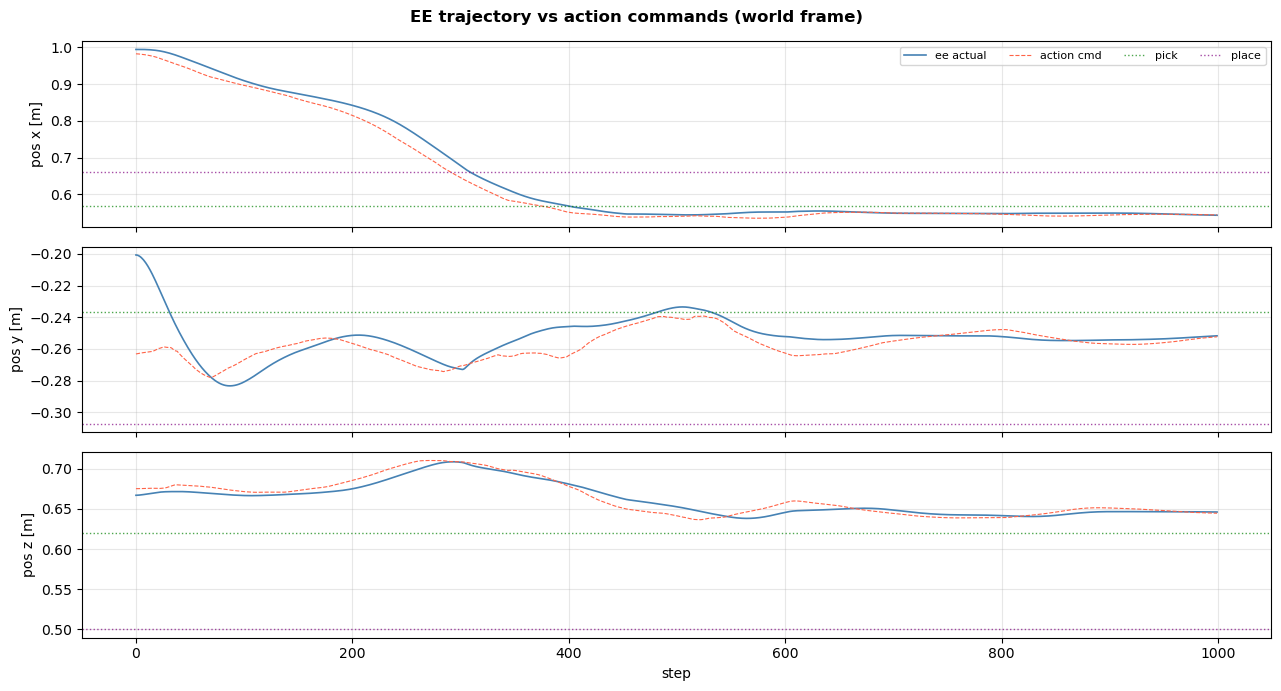

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
labels = ['x', 'y', 'z']
for i, ax in enumerate(axes):
    ax.plot(T, ep['ee_pos'][:, i],    color='steelblue', lw=1.2, label='ee actual')
    ax.plot(T, ep['action'][:, i],    color='tomato',    lw=0.8, ls='--', label='action cmd')
    ax.axhline(ep['pick_pos'][i],  color='green',  lw=1.0, ls=':', alpha=0.7, label='pick')
    ax.axhline(ep['place_pos'][i], color='purple', lw=1.0, ls=':', alpha=0.7, label='place')
    ax.set_ylabel(f'pos {labels[i]} [m]')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8, ncol=4)
axes[-1].set_xlabel('step')
fig.suptitle('EE trajectory vs action commands (world frame)', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Distance to object and place target

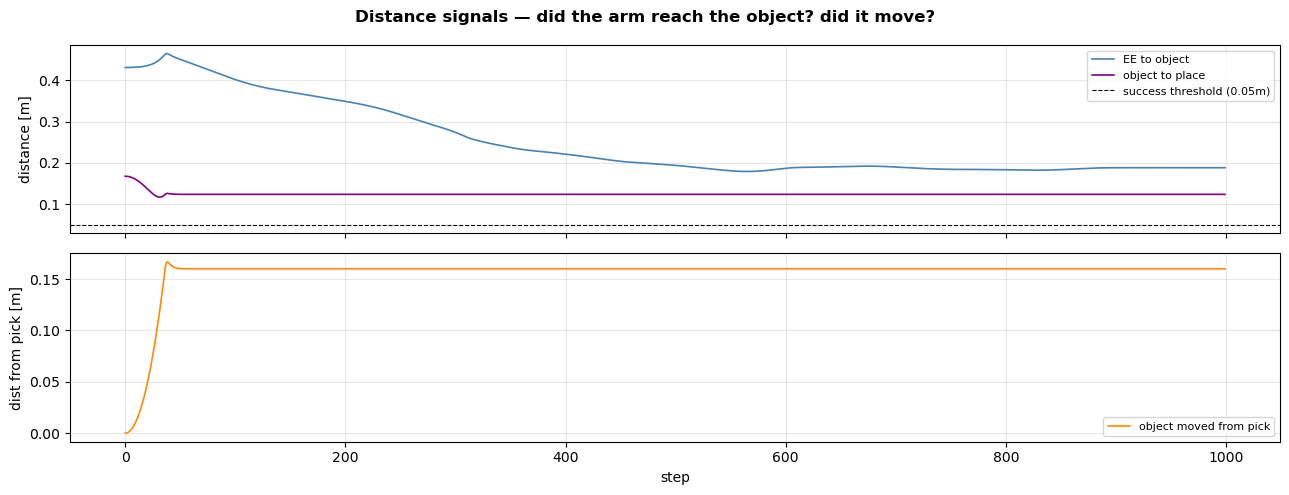

Min EE-to-object distance:  0.1793m at step 564
Max object displacement:    0.1668m
Object ever moved > 2cm:    True


In [7]:
dist_ee_to_obj   = np.linalg.norm(ep['ee_pos'] - ep['obj_pos'], axis=1)
dist_obj_to_pick = np.linalg.norm(ep['obj_pos'] - ep['pick_pos'], axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

axes[0].plot(T, dist_ee_to_obj,        color='steelblue', lw=1.2, label='EE to object')
axes[0].plot(T, ep['dist_to_place'],    color='purple',    lw=1.2, label='object to place')
axes[0].axhline(0.05, color='k', lw=0.8, ls='--', label='success threshold (0.05m)')
axes[0].set_ylabel('distance [m]')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(T, dist_obj_to_pick, color='darkorange', lw=1.2, label='object moved from pick')
axes[1].set_ylabel('dist from pick [m]')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('step')

fig.suptitle('Distance signals — did the arm reach the object? did it move?', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Min EE-to-object distance:  {dist_ee_to_obj.min():.4f}m at step {dist_ee_to_obj.argmin()}')
print(f'Max object displacement:    {dist_obj_to_pick.max():.4f}m')
print(f'Object ever moved > 2cm:    {(dist_obj_to_pick > 0.02).any()}')

## 7. Gripper behavior

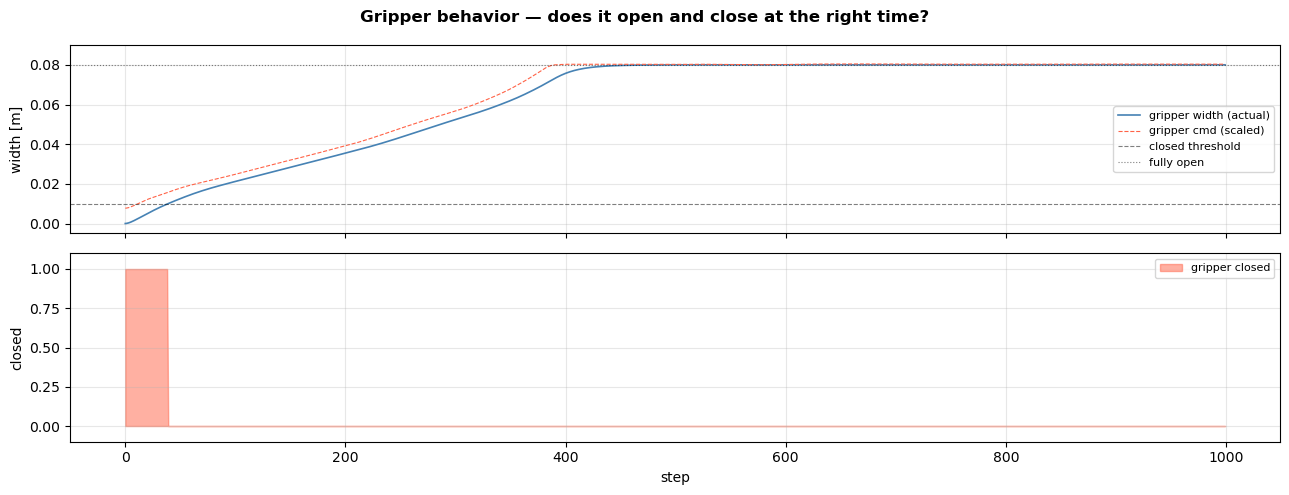

Gripper ever closed (<1cm): True
Gripper cmd range:          [0.097, 1.006]
Steps with gripper closed:  39


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

axes[0].plot(T, ep['gripper_width'],    color='steelblue', lw=1.2, label='gripper width (actual)')
axes[0].plot(T, ep['action'][:, 7] * 0.08, color='tomato', lw=0.8, ls='--', label='gripper cmd (scaled)')
axes[0].axhline(0.01, color='k', lw=0.8, ls='--', alpha=0.5, label='closed threshold')
axes[0].axhline(0.08, color='k', lw=0.8, ls=':',  alpha=0.5, label='fully open')
axes[0].set_ylabel('width [m]')
axes[0].set_ylim(-0.005, 0.09)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

gripper_closed = ep['gripper_width'] < 0.01
axes[1].fill_between(T, 0, gripper_closed.astype(float), color='tomato', alpha=0.5, label='gripper closed')
axes[1].set_ylabel('closed')
axes[1].set_ylim(-0.1, 1.1)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('step')

fig.suptitle('Gripper behavior — does it open and close at the right time?', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Gripper ever closed (<1cm): {gripper_closed.any()}')
print(f'Gripper cmd range:          [{ep["action"][:,7].min():.3f}, {ep["action"][:,7].max():.3f}]')
print(f'Steps with gripper closed:  {gripper_closed.sum()}')

## 8. Object vs EE position (did the arm track the object?)

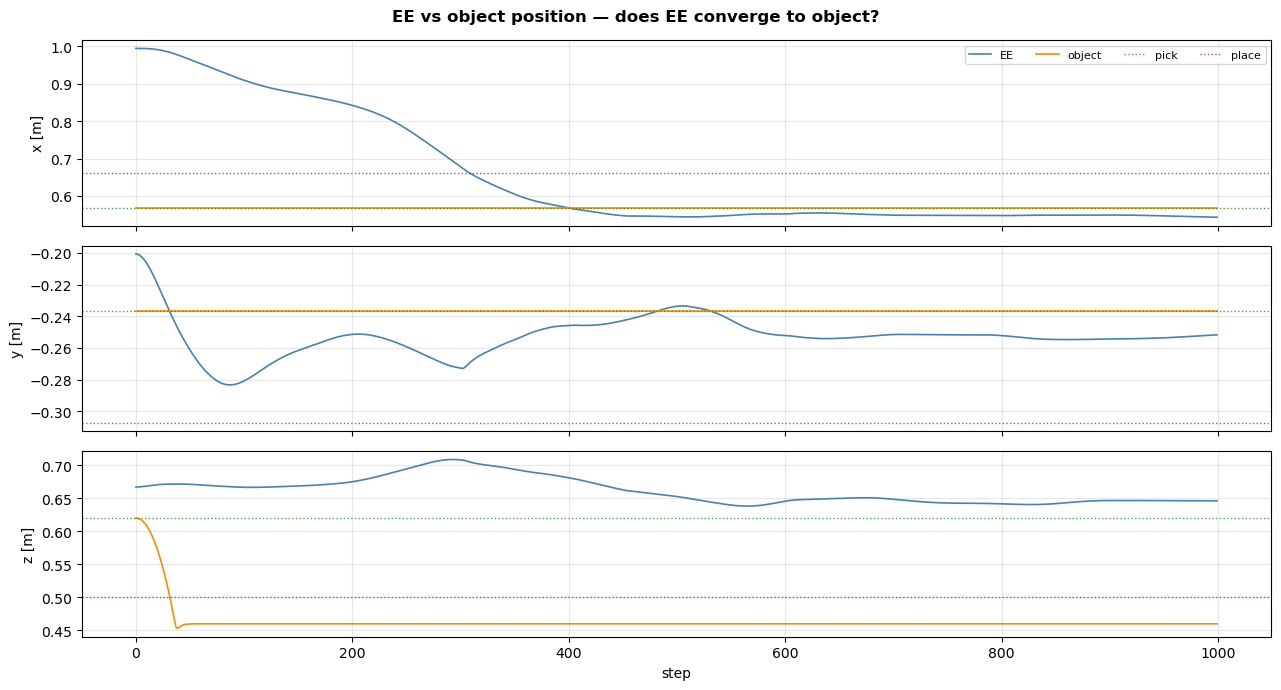

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
labels = ['x', 'y', 'z']
for i, ax in enumerate(axes):
    ax.plot(T, ep['ee_pos'][:, i],  color='steelblue',  lw=1.2, label='EE')
    ax.plot(T, ep['obj_pos'][:, i], color='darkorange',  lw=1.2, label='object')
    ax.axhline(ep['pick_pos'][i],   color='green',  lw=1.0, ls=':', alpha=0.7, label='pick')
    ax.axhline(ep['place_pos'][i],  color='purple', lw=1.0, ls=':', alpha=0.7, label='place')
    ax.set_ylabel(f'{labels[i]} [m]')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8, ncol=4)
axes[-1].set_xlabel('step')
fig.suptitle('EE vs object position — does EE converge to object?', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. 3D trajectory overview

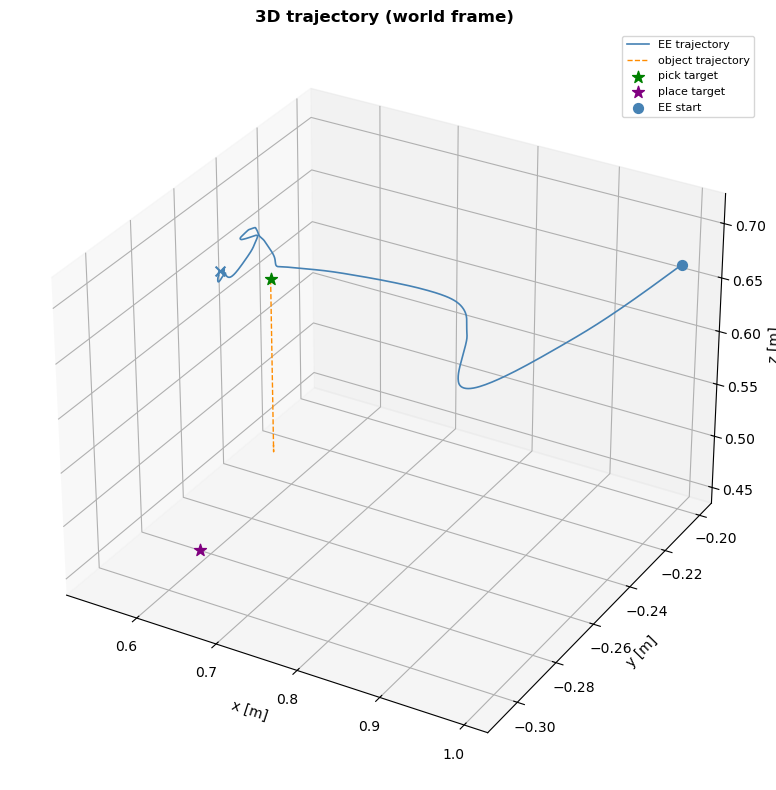

In [10]:
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

ax.plot(ep['ee_pos'][:,0],  ep['ee_pos'][:,1],  ep['ee_pos'][:,2],
        color='steelblue', lw=1.2, label='EE trajectory')
ax.plot(ep['obj_pos'][:,0], ep['obj_pos'][:,1], ep['obj_pos'][:,2],
        color='darkorange', lw=1.0, ls='--', label='object trajectory')

ax.scatter(*ep['pick_pos'],  color='green',  s=80, marker='*', zorder=5, label='pick target')
ax.scatter(*ep['place_pos'], color='purple', s=80, marker='*', zorder=5, label='place target')
ax.scatter(*ep['ee_pos'][0],  color='steelblue', s=50, marker='o', label='EE start')
ax.scatter(*ep['ee_pos'][-1], color='steelblue', s=50, marker='x')

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.legend(fontsize=8)
ax.set_title('3D trajectory (world frame)', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Action analysis — what is the policy commanding?

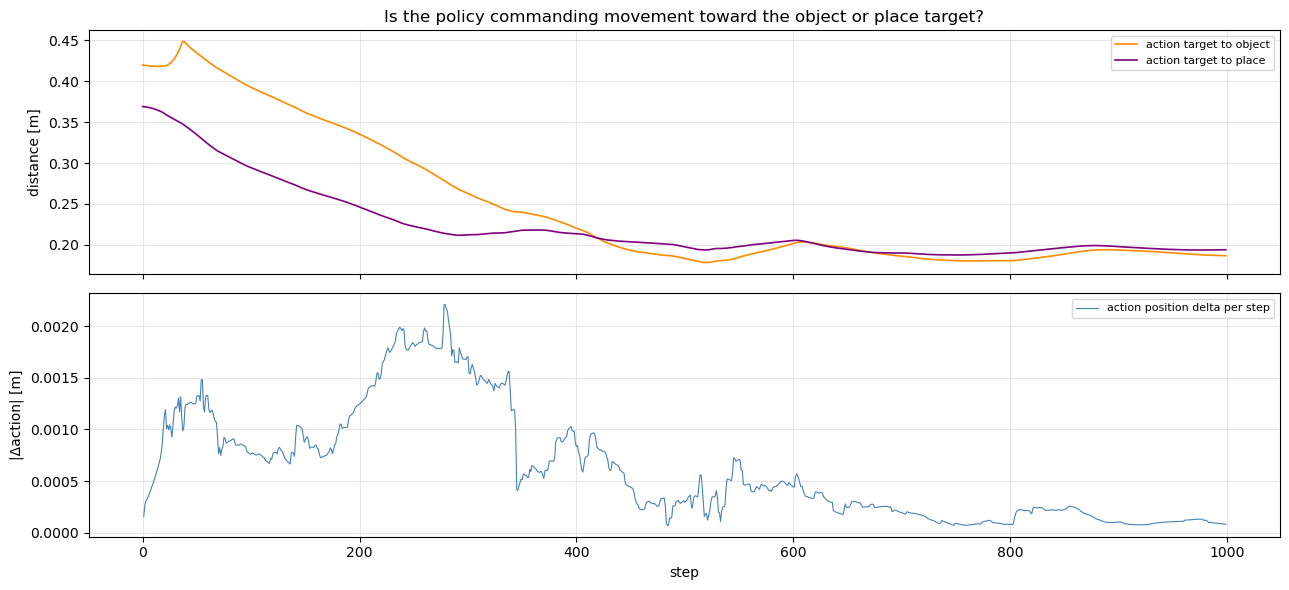

Mean dist action->object:  0.2464m
Min  dist action->object:  0.1785m
Mean action step size:     0.000620m
Max  action step size:     0.002210m


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# Action position vs object position — is the policy pointing at the object?
dist_action_to_obj = np.linalg.norm(ep['action'][:, :3] - ep['obj_pos'], axis=1)
dist_action_to_place = np.linalg.norm(ep['action'][:, :3] - ep['place_pos'], axis=1)

axes[0].plot(T, dist_action_to_obj,   color='darkorange', lw=1.2, label='action target to object')
axes[0].plot(T, dist_action_to_place, color='purple',     lw=1.2, label='action target to place')
axes[0].set_ylabel('distance [m]')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Is the policy commanding movement toward the object or place target?')

# Action smoothness — large jumps indicate policy instability
action_deltas = np.linalg.norm(np.diff(ep['action'][:, :3], axis=0), axis=1)
axes[1].plot(T[1:], action_deltas, color='steelblue', lw=0.8, label='action position delta per step')
axes[1].set_ylabel('|Δaction| [m]')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('step')

plt.tight_layout()
plt.show()

print(f'Mean dist action->object:  {dist_action_to_obj.mean():.4f}m')
print(f'Min  dist action->object:  {dist_action_to_obj.min():.4f}m')
print(f'Mean action step size:     {action_deltas.mean():.6f}m')
print(f'Max  action step size:     {action_deltas.max():.6f}m')

## 11. All episodes — success and distance overview

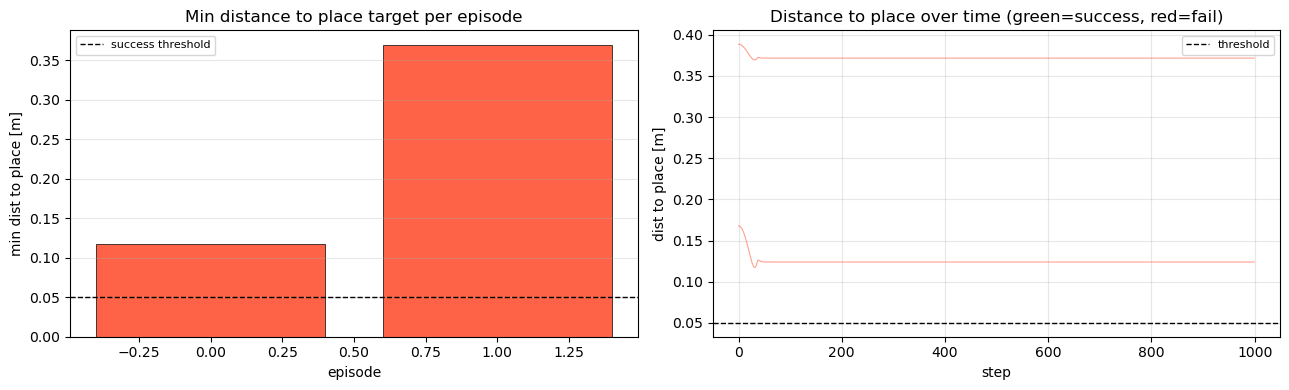

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Min distance to place per episode
min_dists = [e['dist_to_place'].min() for e in episodes]
colors    = ['green' if e['success'] else 'tomato' for e in episodes]
axes[0].bar(range(len(episodes)), min_dists, color=colors, edgecolor='k', linewidth=0.5)
axes[0].axhline(0.05, color='k', lw=1.0, ls='--', label='success threshold')
axes[0].set_xlabel('episode')
axes[0].set_ylabel('min dist to place [m]')
axes[0].set_title('Min distance to place target per episode')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Dist to place over time for all episodes
for e in episodes:
    color = 'green' if e['success'] else 'tomato'
    axes[1].plot(e['dist_to_place'], color=color, lw=0.8, alpha=0.6)
axes[1].axhline(0.05, color='k', lw=1.0, ls='--', label='threshold')
axes[1].set_xlabel('step')
axes[1].set_ylabel('dist to place [m]')
axes[1].set_title('Distance to place over time (green=success, red=fail)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()